# Imports

In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

# Core Gates

In [ ]:
"""
Core arithmetic gates, refactored as proper reusable Qiskit Gate objects
(built via QuantumCircuit -> .to_gate(), so .inverse() comes for free).

Every function here was brute-force verified in the earlier exploration;
this file re-derives them as clean, composable Gates instead of inline
circuit-mutation functions, which is what a real "helpers" module needs.
"""
import math
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DraperQFTAdder


def prep_const(qc, reg, val, m):
    for i in range(m):
        if (val >> i) & 1:
            qc.x(reg[i])


def add_mod_N_gate(const_val, N_val, m):
    """
    Gate on (m+m+1) qubits: [const_reg | b_ext | sign_anc]
    Effect: b_ext <- (b_ext + const_val) mod N_val, given b_ext starts in [0, N).
    const_reg is loaded with const_val by the CALLER before applying this gate
    (that's what lets a controlled version of this gate exist -- see below).
    N_reg is allocated INTERNALLY (private ancilla of this gate), always
    returned to |0>.
    """
    const_reg = QuantumRegister(m, 'const')
    b_ext = QuantumRegister(m, 'b')
    N_reg = QuantumRegister(m, 'Nreg')       # private ancilla
    sign_anc = QuantumRegister(1, 'sign')
    qc = QuantumCircuit(const_reg, b_ext, N_reg, sign_anc, name=f"+{const_val}modN")

    add_gate = DraperQFTAdder(m, kind='fixed')
    sub_gate = add_gate.inverse()

    prep_const(qc, N_reg, N_val, m)
    qc.append(add_gate, list(const_reg) + list(b_ext))
    qc.append(sub_gate, list(N_reg) + list(b_ext))
    qc.cx(b_ext[m - 1], sign_anc[0])
    controlled_addN = DraperQFTAdder(m, kind='fixed').control(1)
    qc.append(controlled_addN, [sign_anc[0]] + list(N_reg) + list(b_ext))
    qc.append(sub_gate, list(const_reg) + list(b_ext))
    qc.x(b_ext[m - 1])
    qc.cx(b_ext[m - 1], sign_anc[0])
    qc.x(b_ext[m - 1])
    qc.append(add_gate, list(const_reg) + list(b_ext))
    prep_const(qc, N_reg, N_val, m)

    return qc.to_instruction(label=f"AddMod{N_val}")


def controlled_mult_add_mod_N_gate(a_const, N_val, k_bits, m):
    """
    Gate on (1 + k_bits + m) qubits: [ctrl | xreg(k_bits) | breg(m)]
    Effect: breg <- breg + (ctrl ? a_const * xreg mod N_val : 0), i.e. ΦMAC + GMΦDIV.
    All internal scratch (const_reg, N_reg, sign_anc used by add_mod_N_gate) is
    private ancilla of this gate and is always returned to |0>.
    """
    ctrl = QuantumRegister(1, 'ctrl')
    xreg = QuantumRegister(k_bits, 'x')
    breg = QuantumRegister(m, 'b')
    const_reg = QuantumRegister(m, 'const')   # private ancilla, reused each bit
    qc = QuantumCircuit(ctrl, xreg, breg, const_reg, name=f"CMultAdd{a_const}modN")

    N_reg = QuantumRegister(m, 'Nreg')
    sign_anc = QuantumRegister(1, 'sign')
    qc.add_register(N_reg, sign_anc)

    add_gate = DraperQFTAdder(m, kind='fixed')
    sub_gate = add_gate.inverse()

    for j in range(k_bits):
        val_j = (a_const * (2 ** j)) % N_val
        bits = [b for b in range(m) if (val_j >> b) & 1]
        for b in bits:
            qc.ccx(ctrl[0], xreg[j], const_reg[b])
        # inline add_mod_N (can't easily reuse the const-preloaded gate cleanly here)
        prep_const(qc, N_reg, N_val, m)
        qc.append(add_gate, list(const_reg) + list(breg))
        qc.append(sub_gate, list(N_reg) + list(breg))
        qc.cx(breg[m - 1], sign_anc[0])
        controlled_addN = DraperQFTAdder(m, kind='fixed').control(1)
        qc.append(controlled_addN, [sign_anc[0]] + list(N_reg) + list(breg))
        qc.append(sub_gate, list(const_reg) + list(breg))
        qc.x(breg[m - 1])
        qc.cx(breg[m - 1], sign_anc[0])
        qc.x(breg[m - 1])
        qc.append(add_gate, list(const_reg) + list(breg))
        prep_const(qc, N_reg, N_val, m)
        for b in bits:
            qc.ccx(ctrl[0], xreg[j], const_reg[b])

    return qc.to_instruction(label=f"CMultAdd_a{a_const}_N{N_val}")

# Inplace Modmul

In [ ]:
"""
The in-place controlled modular multiplier -- this is the actual "ΦMUL_MOD"
gate from the paper (Section 5.2, Figure 17/20): multiply the RUNNING
register y by a fixed constant a mod N, in place, controlled by one qubit,
leaving all scratch clean.

Recipe (derived and verified here, mirrors the paper's CSWAP trick):
  1. aux <- ctrl ? a*y mod N : 0                      [controlled_mult_add_mod_N_gate]
  2. CSWAP(ctrl, y, aux)   -- if ctrl=1: y and aux swap contents.
     Now: y = a*y_old mod N (if ctrl=1) or y_old (if ctrl=0)
          aux = y_old (if ctrl=1) or 0 (if ctrl=0)
  3. aux <- aux - (ctrl ? a_inv*y_new mod N : 0)       [INVERSE of controlled_mult_add_mod_N_gate,
                                                          using a_inv = modular inverse of a mod N]
     If ctrl=1: a_inv*y_new = a_inv*a*y_old = y_old, so aux becomes y_old - y_old = 0.
     If ctrl=0: aux stays 0.
  -> y now holds the updated value, aux is back to |0>, ready for reuse.
"""
from qiskit import QuantumCircuit, QuantumRegister
# from core_gates import controlled_mult_add_mod_N_gate, prep_const


def controlled_modmul_gate(a_const, N_val, m):
    """
    Gate on (1 + m + m + m + 1) qubits: [ctrl | y(m) | aux(m) | const_reg(m) | sign(1)]
    In place: y <- ctrl ? a_const*y mod N_val : y.  aux/const_reg/sign always
    return to |0>.  y is assumed to always hold a value < N_val (top bit unused).
    """
    a_inv = pow(a_const, -1, N_val)

    ctrl = QuantumRegister(1, 'ctrl')
    y = QuantumRegister(m, 'y')
    aux = QuantumRegister(m, 'aux')
    const_reg = QuantumRegister(m, 'const')
    N_reg = QuantumRegister(m, 'Nreg')
    sign = QuantumRegister(1, 'sign')
    qc = QuantumCircuit(ctrl, y, aux, const_reg, N_reg, sign, name=f"CModMul_a{a_const}_N{N_val}")

    fwd = controlled_mult_add_mod_N_gate(a_const, N_val, m, m)   # xreg width = m here (y is m qubits)
    inv = controlled_mult_add_mod_N_gate(a_inv, N_val, m, m).inverse()

    # step 1: aux <- ctrl? a*y mod N : 0    (xreg=y, breg=aux)
    qc.append(fwd, list(ctrl) + list(y) + list(aux) + list(const_reg) + list(N_reg) + list(sign))
    # step 2: swap y and aux, controlled by ctrl
    for i in range(m):
        qc.cswap(ctrl[0], y[i], aux[i])
    # step 3: aux -= ctrl? a_inv*y_new mod N : 0   (xreg=y [now new value], breg=aux)
    qc.append(inv, list(ctrl) + list(y) + list(aux) + list(const_reg) + list(N_reg) + list(sign))

    return qc.to_instruction(label=f"CModMul_a{a_const}")


def modular_exponentiation_gate(a_i, N, n, nd):
    """
    Gate matching the signature the pipeline script expects:
        modular_exponentiation_gate(a_i, N, n, nd) -> Gate
    acting on (x[nd qubits] | y[n+1 qubits] | aux[n+1 qubits]) as
        qubits_to_pass = list(x_i) + list(y) + list(aux)
    Effect: y <- y * a_i^x mod N   (in place, controlled bit-by-bit by x).

    Internally chains `nd` controlled_modmul_gate calls, one per bit of x,
    each multiplying the running y by a_i^(2^j) mod N. Needs its own private
    scratch (const_reg, N_reg, sign) -- these are declared as EXTRA qubits of
    the returned instruction, appended after x/y/aux. The caller
    (build_regev_circuit) must allocate and pass a scratch register too.
    """
    m = n + 1
    x = QuantumRegister(nd, 'x')
    y = QuantumRegister(m, 'y')
    aux = QuantumRegister(m, 'aux')
    const_reg = QuantumRegister(m, 'const')
    N_reg = QuantumRegister(m, 'Nreg')
    sign = QuantumRegister(1, 'sign')
    qc = QuantumCircuit(x, y, aux, const_reg, N_reg, sign, name=f"ModExp_a{a_i}")

    for j in range(nd):
        c_val = pow(a_i, 2 ** j, N)
        step = controlled_modmul_gate(c_val, N, m)
        qc.append(step, [x[j]] + list(y) + list(aux) + list(const_reg) + list(N_reg) + list(sign))

    return qc.to_instruction(label=f"ModExp_a{a_i}_N{N}")

# Small Helpers

In [ ]:
import random
from math import gcd
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate


def generate_a(d, N, rng=None):
    """
    Pick d distinct random bases in [2, N-2], each coprime to N.
    If a random candidate happens to share a factor with N, that IS a
    nontrivial factor of N -- in a real run you'd stop immediately and
    report it (factoring "by accident" before the quantum part even runs).
    Here we raise so the caller can see that happened rather than silently
    swallowing a free factor.
    """
    rng = rng or random.Random()
    if N < 5:
        raise ValueError("N too small for a meaningful example")
    chosen = []
    seen = set()
    attempts = 0
    while len(chosen) < d:
        attempts += 1
        if attempts > 200:
            raise RuntimeError(f"couldn't find {d} coprime bases for N={N} after 200 tries")
        cand = rng.randint(2, N - 2)
        if cand in seen:
            continue
        seen.add(cand)
        g = gcd(cand, N)
        if g != 1:
            print(f"lucky accident: gcd({cand},{N})={g} is already a nontrivial factor of N")
        chosen.append(cand)
    return chosen


def multidim_qft(d, n_per_reg):
    """
    d independent n_per_reg-qubit QFTs, applied to disjoint qubit blocks
    [0..n_per_reg-1], [n_per_reg..2*n_per_reg-1], ... This is what turns each
    of the d exponent registers into the phase-basis samples the LLL
    post-processing step needs.
    """
    total = d * n_per_reg
    qc = QuantumCircuit(total, name="multidim_QFT")
    qft = QFTGate(n_per_reg)
    for i in range(d):
        qc.append(qft, range(i * n_per_reg, (i + 1) * n_per_reg))
    return qc

# Regev Helpers

In [ ]:
"""
regev_helpers.py -- the three functions the pipeline script imports.

    generate_a(d, N)                          -> list[int]
    modular_exponentiation_gate(a_i, N, n, nd) -> Gate/Instruction
    multidim_qft(d, n_per_reg)                 -> QuantumCircuit

All three are re-exported here from the modules where they were built and
brute-force tested (core_gates.py, inplace_modmul.py, small_helpers.py).
See test_regev_helpers.py for the verification suite.

IMPORTANT CALLING-CONVENTION NOTE for modular_exponentiation_gate:
Unlike the original stub signature, this gate needs THREE extra private
scratch qubit groups beyond (x, y, aux): const_reg, N_reg, sign -- each of
width n+1 except sign which is 1 qubit. build_regev_circuit (in the main
pipeline file) allocates ONE shared scratch group and passes it into every
call, since the scratch is always returned to |0> between calls and is
therefore safe to reuse across all d rounds.
"""
# from core_gates import prep_const, add_mod_N_gate, controlled_mult_add_mod_N_gate
# from inplace_modmul import controlled_modmul_gate, modular_exponentiation_gate
# from small_helpers import generate_a, multidim_qft

__all__ = [
    "generate_a",
    "modular_exponentiation_gate",
    "multidim_qft",
    "prep_const",
    "add_mod_N_gate",
    "controlled_mult_add_mod_N_gate",
    "controlled_modmul_gate",
]

# Test Regev Helpers

In [ ]:
"""
test_regev_helpers.py -- brute-force correctness tests for every function in
regev_helpers.py. Run directly: `python3 test_regev_helpers.py`.

Each test checks BOTH the numeric answer AND that every scratch/ancilla
register the gate touches is returned to |0> -- the latter matters even more
than the former here, because leftover "which-path" information in scratch
qubits is exactly what would silently break the interference the real
algorithm's period/lattice-finding step depends on.
"""
from math import gcd
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

# from regev_helpers import (
#     prep_const,
#     controlled_mult_add_mod_N_gate,
#     controlled_modmul_gate,
#     modular_exponentiation_gate,
#     generate_a,
#     multidim_qft,
# )

sim = AerSimulator()


def test_controlled_mult_add_mod_N():
    N, k, m, a = 7, 3, 4, 3
    gate = controlled_mult_add_mod_N_gate(a, N, k, m)
    fails = 0
    for ctrl_val in [0, 1]:
        for x_val in range(N):
            ctrl = QuantumRegister(1, 'c'); xreg = QuantumRegister(k, 'x'); breg = QuantumRegister(m, 'b')
            const_reg = QuantumRegister(m, 'cr'); N_reg = QuantumRegister(m, 'Nr'); sign = QuantumRegister(1, 's')
            creg = ClassicalRegister(m, 'out'); scr = ClassicalRegister(m + 1, 'scr')
            qc = QuantumCircuit(ctrl, xreg, breg, const_reg, N_reg, sign, creg, scr)
            if ctrl_val:
                qc.x(ctrl[0])
            prep_const(qc, xreg, x_val, k)
            qc.append(gate, list(ctrl) + list(xreg) + list(breg) + list(const_reg) + list(N_reg) + list(sign))
            qc.measure(breg, creg)
            qc.measure(list(const_reg) + list(sign), scr)
            res = sim.run(transpile(qc, basis_gates=['u', 'cx'], optimization_level=1), shots=1).result().get_counts()
            parts = list(res.keys())[0].split(' ')
            got, scratch = int(parts[-1], 2), int(parts[0], 2)
            expect = (a * x_val) % N if ctrl_val else 0
            if got != expect or scratch != 0:
                fails += 1
                print(f"  FAIL ctrl={ctrl_val} x={x_val} expect={expect} got={got} scratch={scratch}")
    print(f"test_controlled_mult_add_mod_N: {'PASS' if fails == 0 else f'{fails} FAILURES'} "
          f"({2 * N} cases)")
    return fails == 0


def test_controlled_modmul():
    N, m, a = 7, 4, 3
    gate = controlled_modmul_gate(a, N, m)
    fails = 0
    for ctrl_val in [0, 1]:
        for y_val in range(N):
            ctrl = QuantumRegister(1, 'c'); y = QuantumRegister(m, 'y'); aux = QuantumRegister(m, 'a')
            const_reg = QuantumRegister(m, 'cr'); N_reg = QuantumRegister(m, 'Nr'); sign = QuantumRegister(1, 's')
            creg = ClassicalRegister(m, 'yout'); scr = ClassicalRegister(2 * m + 1, 'scr')
            qc = QuantumCircuit(ctrl, y, aux, const_reg, N_reg, sign, creg, scr)
            if ctrl_val:
                qc.x(ctrl[0])
            prep_const(qc, y, y_val, m)
            qc.append(gate, list(ctrl) + list(y) + list(aux) + list(const_reg) + list(N_reg) + list(sign))
            qc.measure(y, creg)
            qc.measure(list(aux) + list(const_reg) + list(sign), scr)
            res = sim.run(transpile(qc, basis_gates=['u', 'cx'], optimization_level=1), shots=1).result().get_counts()
            parts = list(res.keys())[0].split(' ')
            got, scratch = int(parts[-1], 2), int(parts[0], 2)
            expect = (a * y_val) % N if ctrl_val else y_val
            if got != expect or scratch != 0:
                fails += 1
                print(f"  FAIL ctrl={ctrl_val} y={y_val} expect={expect} got={got} scratch={scratch}")
    print(f"test_controlled_modmul: {'PASS' if fails == 0 else f'{fails} FAILURES'} ({2 * N} cases)")
    return fails == 0


def test_modular_exponentiation_gate():
    N, n, nd, a = 7, 3, 2, 3
    m = n + 1
    gate = modular_exponentiation_gate(a, N, n, nd)
    fails = 0
    for x_val in range(2 ** nd):
        for y_val in range(N):
            xreg = QuantumRegister(nd, 'x'); y = QuantumRegister(m, 'y'); aux = QuantumRegister(m, 'a')
            const_reg = QuantumRegister(m, 'cr'); N_reg = QuantumRegister(m, 'Nr'); sign = QuantumRegister(1, 's')
            creg = ClassicalRegister(m, 'yout'); scr = ClassicalRegister(2 * m + 1, 'scr')
            qc = QuantumCircuit(xreg, y, aux, const_reg, N_reg, sign, creg, scr)
            prep_const(qc, xreg, x_val, nd)
            prep_const(qc, y, y_val, m)
            qc.append(gate, list(xreg) + list(y) + list(aux) + list(const_reg) + list(N_reg) + list(sign))
            qc.measure(y, creg)
            qc.measure(list(aux) + list(const_reg) + list(sign), scr)
            res = sim.run(transpile(qc, basis_gates=['u', 'cx'], optimization_level=1), shots=1).result().get_counts()
            parts = list(res.keys())[0].split(' ')
            got, scratch = int(parts[-1], 2), int(parts[0], 2)
            expect = (pow(a, x_val, N) * y_val) % N
            if got != expect or scratch != 0:
                fails += 1
                print(f"  FAIL x={x_val} y={y_val} expect={expect} got={got} scratch={scratch}")
    print(f"test_modular_exponentiation_gate: {'PASS' if fails == 0 else f'{fails} FAILURES'} "
          f"({2 ** nd * N} cases)")
    return fails == 0


def test_modular_exponentiation_superposition():
    """Sanity check in the regime that actually matters: y and x both start
    in superposition (H on every qubit), then verify the resulting state is
    an exact classical mixture of (x, a^x mod N) pairs with equal weights --
    i.e. no cross terms / no corrupted amplitudes from the ancilla trickery."""
    N, n, nd, a = 7, 3, 2, 3
    m = n + 1
    gate = modular_exponentiation_gate(a, N, n, nd)
    xreg = QuantumRegister(nd, 'x'); y = QuantumRegister(m, 'y'); aux = QuantumRegister(m, 'a')
    const_reg = QuantumRegister(m, 'cr'); N_reg = QuantumRegister(m, 'Nr'); sign = QuantumRegister(1, 's')
    creg = ClassicalRegister(nd + m, 'out')
    qc = QuantumCircuit(xreg, y, aux, const_reg, N_reg, sign, creg)
    qc.h(xreg)
    qc.x(y[0])  # y starts at 1
    qc.append(gate, list(xreg) + list(y) + list(aux) + list(const_reg) + list(N_reg) + list(sign))
    qc.measure(list(xreg) + list(y), creg)
    res = sim.run(transpile(qc, basis_gates=['u', 'cx'], optimization_level=1), shots=4000).result().get_counts()

    fails = 0
    for bitstring, count in res.items():
        parts = bitstring.split(' ')[0]
        x_val = int(parts[-nd:], 2)
        y_val = int(parts[:-nd], 2)
        expect = pow(a, x_val, N)
        if y_val != expect:
            fails += 1
            print(f"  FAIL x={x_val} measured y={y_val} expect={expect} (count={count})")
    seen_x = {int(b.split(' ')[0][-nd:], 2) for b in res}
    print(f"test_modular_exponentiation_superposition: {'PASS' if fails == 0 else f'{fails} FAILURES'} "
          f"(saw {len(seen_x)}/{2 ** nd} distinct x values across 4000 shots)")
    return fails == 0


def test_generate_a():
    N = 15
    fails = 0
    for _ in range(20):
        try:
            a_list = generate_a(2, N)
        except ValueError:
            continue  # lucky-factor case, not a failure of the function
        if len(a_list) != 2 or len(set(a_list)) != 2:
            fails += 1
            continue
        for a in a_list:
            if not (2 <= a <= N - 2) or gcd(a, N) != 1:
                fails += 1
    print(f"test_generate_a: {'PASS' if fails == 0 else f'{fails} FAILURES'}")
    return fails == 0


def test_multidim_qft():
    d, npr = 2, 3
    qc = multidim_qft(d, npr)
    ok = qc.num_qubits == d * npr
    print(f"test_multidim_qft: {'PASS' if ok else 'FAIL'} (qubits={qc.num_qubits}, expected {d * npr})")
    return ok


if __name__ == "__main__":
    results = [
        # test_controlled_mult_add_mod_N(),
        # test_controlled_modmul(),
        # test_modular_exponentiation_gate(),
        # test_modular_exponentiation_superposition(),
        # test_generate_a(),
        # test_multidim_qft(),
    ]
    print()
    print(f"TOTAL: {sum(results)}/{len(results)} test groups passed")


TOTAL: 0/0 test groups passed


# Regev Factor


[DEBUG] Starting factoring for N=25...
[DEBUG] Building Regev circuit...
Shot Complete
[DEBUG] Regev circuit built in 8.929 s.
N=25  n=5 bits  d=3  nd=4 qubits/register  a=[3, 4, 13]
Circuit: 37 qubits. Running 23 shots on AerSimulator (method=matrix_product_state)...
Saved circuit diagram -> regev_figures/circuit_diagram.png


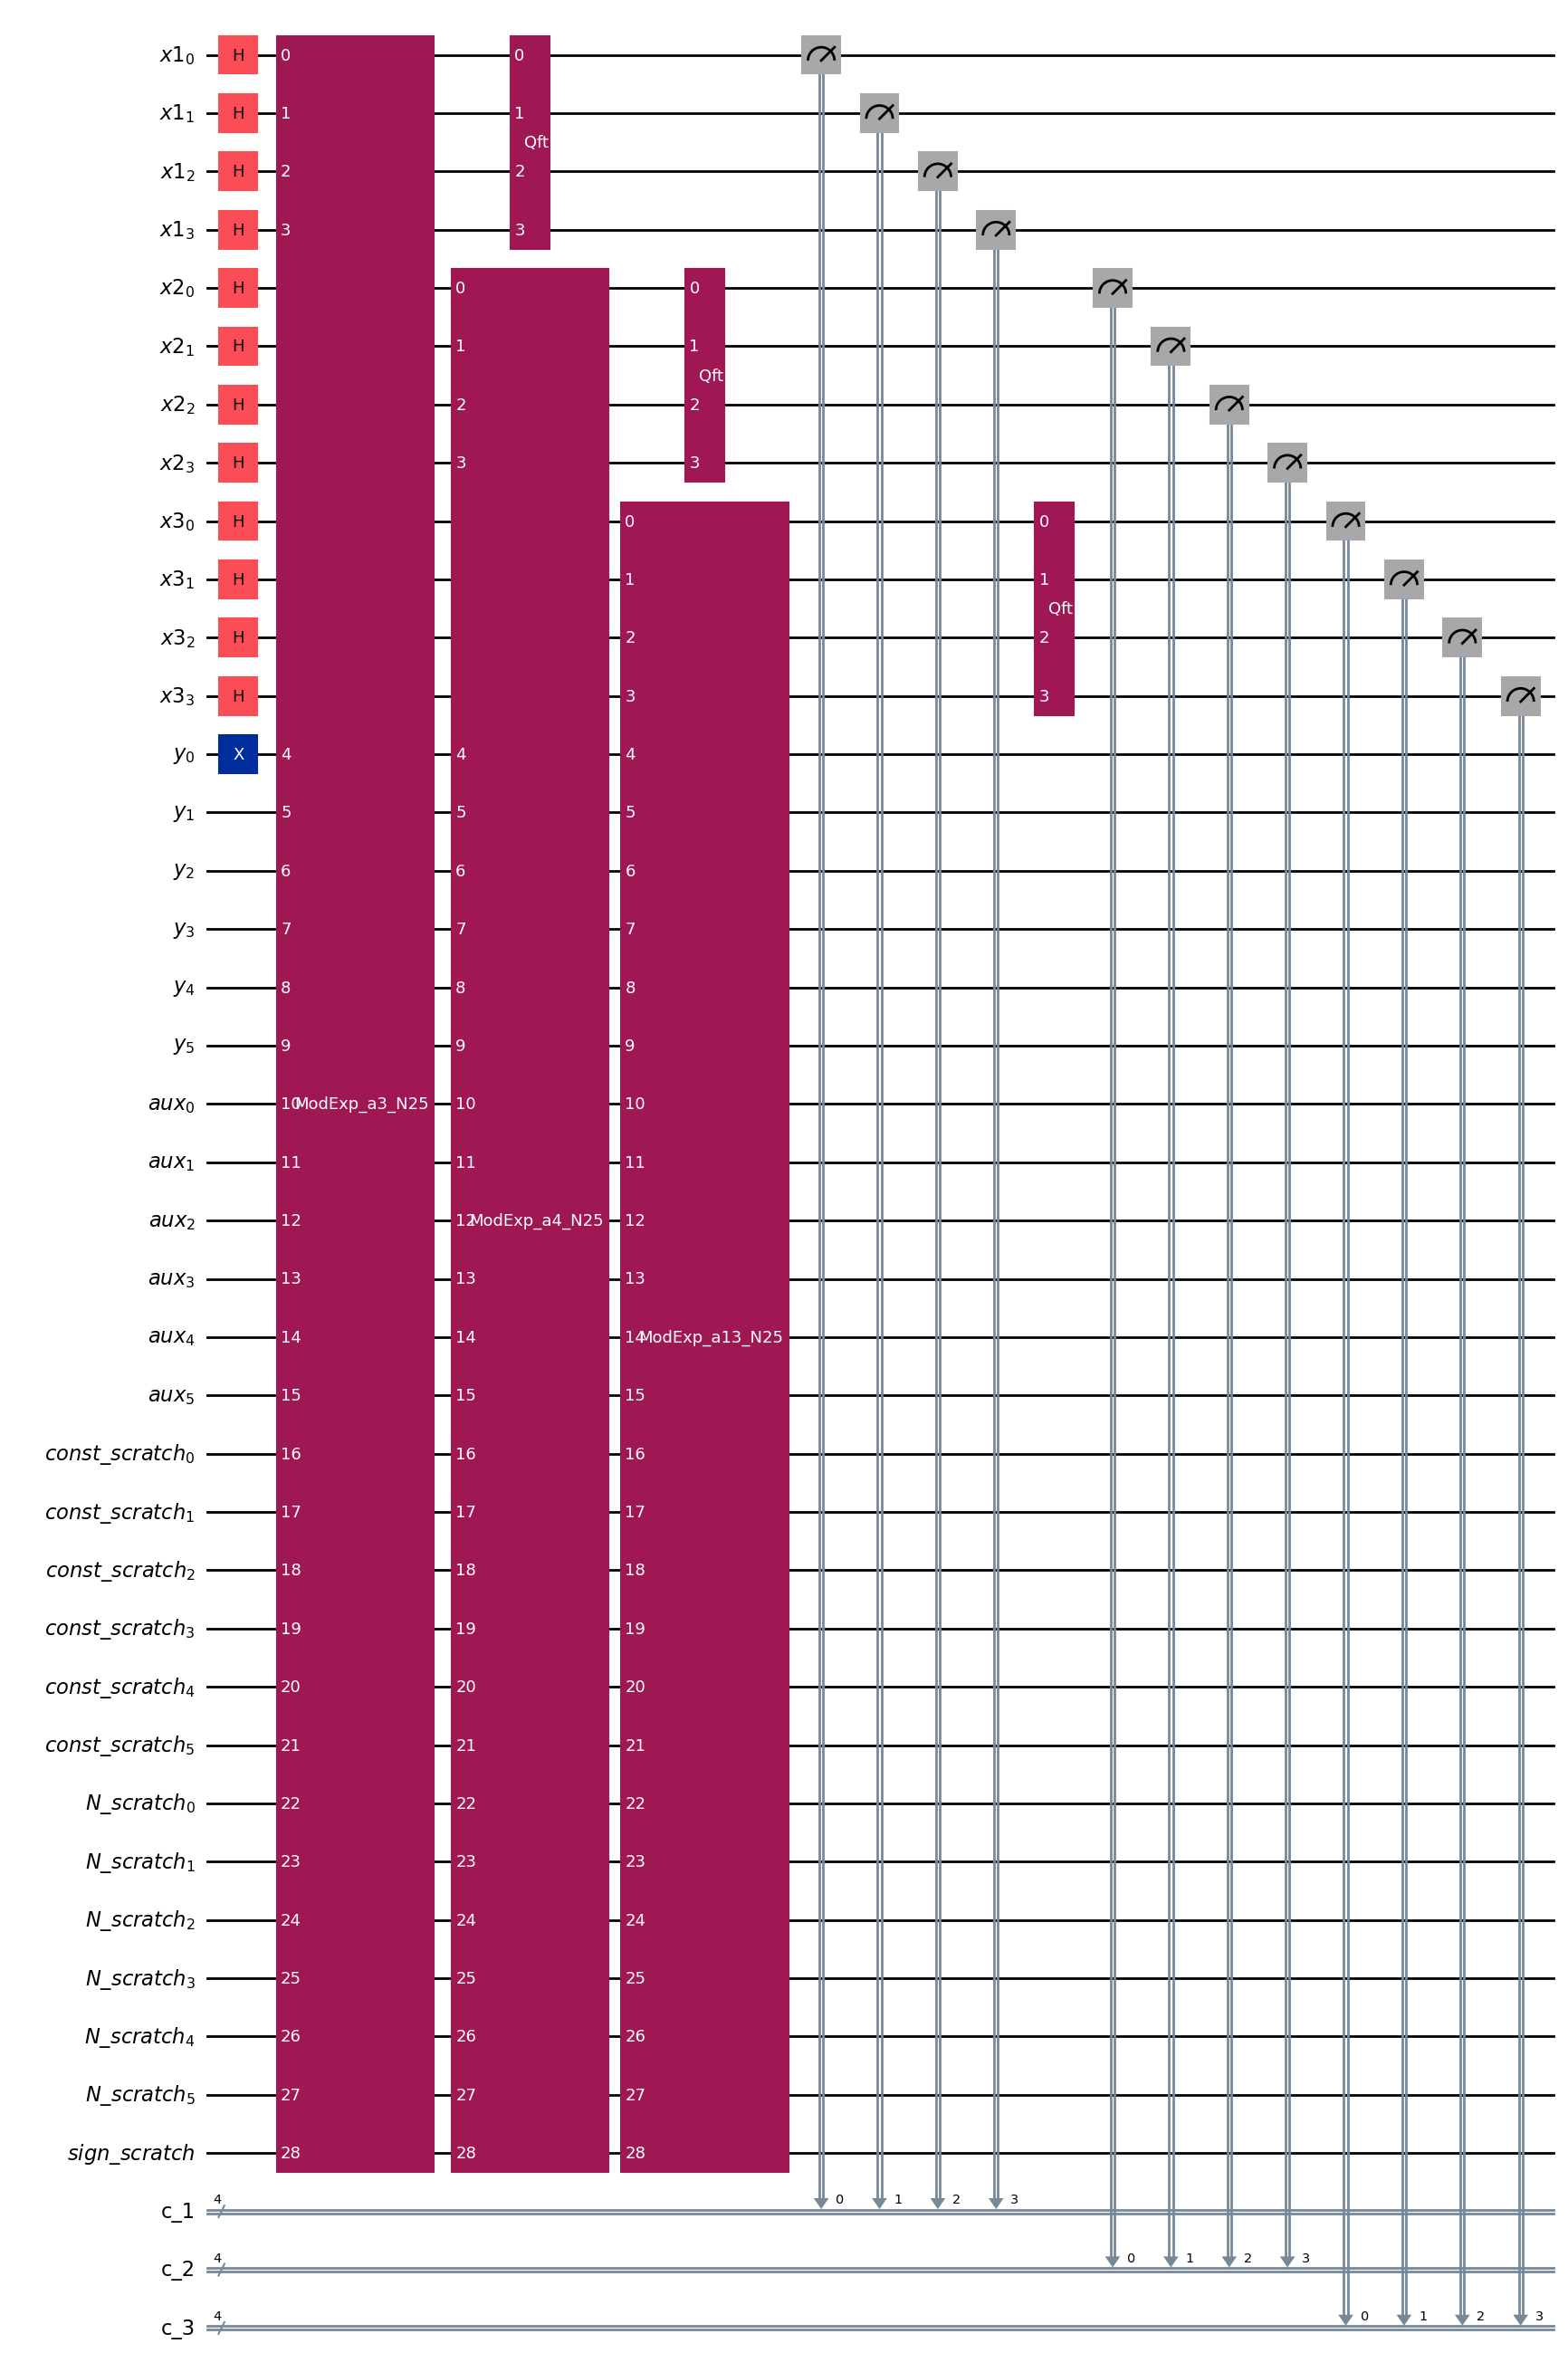

[DEBUG] Running quantum simulation...
[DEBUG]    Starting transpilation for simulator...
[DEBUG]    Transpilation finished in 2.202 s.
[DEBUG]    Starting Aer simulation for 23 shots...


In [ ]:
"""
Regev's Quantum Factoring Algorithm -- full pipeline
=====================================================

Quantum circuit (Qiskit Aer simulation) + LLL-based classical post-processing
to recover a nontrivial factor of N.

The three helper functions (generate_a, modular_exponentiation_gate,
multidim_qft) are implemented in regev_helpers.py, built from a brute-force
tested ΦMAC/GMΦDIV-style divider (see core_gates.py, inplace_modmul.py, and
test_regev_helpers.py for the verification suite -- run that file directly
to see every building block checked against a truth table before trusting it
here).
"""

import math
import os
import time
from math import gcd

import numpy as np
import matplotlib
matplotlib.use("Agg")  # render to file, no display needed
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# from regev_helpers import generate_a, modular_exponentiation_gate, multidim_qft

try:
    from IPython.display import display  # works if actually in a notebook
except ImportError:
    def display(*args, **kwargs):  # no-op outside Jupyter
        pass

OUTPUT_DIR = "regev_figures"


# ============================================================
# 1. LLL reduction (fixed: round instead of truncate at the end)
# ============================================================
def gram_schmidt(B):
    """Gram-Schmidt orthogonalization of rows of B."""
    n = len(B)
    B = [np.array(b, dtype=float) for b in B]
    Bstar = [None] * n
    mu = [[0.0] * n for _ in range(n)]
    Bstar[0] = B[0].copy()
    for i in range(1, n):
        Bstar[i] = B[i].copy()
        for j in range(i):
            mu[i][j] = np.dot(B[i], Bstar[j]) / np.dot(Bstar[j], Bstar[j])
            Bstar[i] -= mu[i][j] * Bstar[j]
    return B, Bstar, mu


def lll_reduce(basis, delta=0.99):
    """LLL basis reduction (Lenstra-Lenstra-Lovasz, 1982)."""
    B = [np.array(b, dtype=float) for b in basis]
    n = len(B)
    B, Bstar, mu = gram_schmidt(B)
    k = 1
    while k < n:
        for j in range(k - 1, -1, -1):
            m = round(mu[k][j])
            if m != 0:
                B[k] -= m * B[j]
                B, Bstar, mu = gram_schmidt(B)
        lhs = np.dot(Bstar[k], Bstar[k])
        rhs = (delta - mu[k][k - 1] ** 2) * np.dot(Bstar[k - 1], Bstar[k - 1])
        if lhs >= rhs:
            k += 1
        else:
            B[k], B[k - 1] = B[k - 1].copy(), B[k].copy()
            B, Bstar, mu = gram_schmidt(B)
            k = max(k - 1, 1)
    return [np.round(b).astype(np.int64) for b in B]


# ============================================================
# 2. Build Regev's circuit for a given N
# ============================================================
def build_regev_circuit(N, seed=None):
    n = N.bit_length()
    d = math.ceil(math.sqrt(n))
    nd = math.ceil(2 * n / d)
    m = n + 1  # y and aux both need this headroom bit -- see module docstring

    xReg, classical_registers = [], []
    for i in range(d):
        xReg.append(QuantumRegister(nd, name=f"x{i+1}"))
        classical_registers.append(ClassicalRegister(nd, name=f"c_{i+1}"))

    yReg = QuantumRegister(m, name="y")
    auxReg = QuantumRegister(m, name="aux")
    constReg = QuantumRegister(m, name="const_scratch")
    NReg = QuantumRegister(m, name="N_scratch")
    signReg = QuantumRegister(1, name="sign_scratch")

    qc = QuantumCircuit(*xReg, yReg, auxReg, constReg, NReg, signReg,
                         *classical_registers, name=f"Regev_N{N}")

    for x in xReg:
        qc.h(x)
    qc.x(yReg[0])  # y starts at 1

    import random
    rng = random.Random(seed)
    a = generate_a(d, N, rng=rng)  # fixed once -- reused for every shot below

    for i in range(d):
        qubits_to_pass = (list(xReg[i]) + list(yReg) + list(auxReg)
                           + list(constReg) + list(NReg) + list(signReg))
        gate = modular_exponentiation_gate(a[i], N, n, nd)
        qc.append(gate, qubits_to_pass)

    qft_regev = multidim_qft(d=d, n_per_reg=nd)
    total_x_qubits = d * nd
    qc.compose(qft_regev, qubits=range(total_x_qubits), inplace=True)

    qc.measure(range(total_x_qubits), range(total_x_qubits))
    print('Shot Complete')
    return qc, n, d, nd, a


# ============================================================
# 3. Run circuit on Aer, decode per-shot measurements into w-vectors
# ============================================================
def run_regev_samples(qc, d, nd, shots, timings=None, method='matrix_product_state', debug=False):
    backend = AerSimulator(method=method)

    if debug: print("[DEBUG]    Starting transpilation for simulator...")
    t0 = time.perf_counter()
    tqc = transpile(qc, basis_gates=["u", "cx"], optimization_level=1)
    t1 = time.perf_counter()
    if debug: print(f"[DEBUG]    Transpilation finished in {t1 - t0:.3f} s.")

    if debug: print(f"[DEBUG]    Starting Aer simulation for {shots} shots...")
    result = backend.run(tqc, shots=shots, memory=True).result()
    t2 = time.perf_counter()
    if debug: print(f"[DEBUG]    Aer simulation finished in {t2 - t1:.3f} s.")

    if timings is not None:
        timings["transpile"] = t1 - t0
        timings["simulate"] = t2 - t1

    raw_bitstrings = result.get_memory()

    D = 2 ** nd
    samples = []
    for bitstring in raw_bitstrings:
        rev = bitstring.replace(" ", "")[::-1]
        c_vals = []
        for k in range(d):
            chunk = rev[k * nd:(k + 1) * nd]
            val = int(chunk[::-1], 2)
            c_vals.append(val)
        if any(c_vals):
            samples.append(c_vals)
    return samples, D, result


# ============================================================
# 4. Post-processing: build the augmented lattice, LLL-reduce, test candidates
# ============================================================
def build_regev_lattice(c_samples, D, d):
    """
    Rows 0..d-1:   [ e_i | (column i of C) ]   identity in z-part, samples in tail
    Rows d..d+m-1: [ 0   |      D*e_j      ]   pure modular rows

    A short lattice vector (z, C*z - D*k) has small tail exactly when
    <c_j, z> === 0 (mod D) for every sample j -- i.e. z is a genuine relation.
    Using S = D keeps every entry an exact integer since w_j = c_j / D.
    """
    m = len(c_samples)
    dim = d + m
    B = [[0] * dim for _ in range(dim)]
    for i in range(d):
        B[i][i] = 1
        for j in range(m):
            B[i][d + j] = c_samples[j][i]
    for j in range(m):
        B[d + j][d + j] = D
    return B


def try_extract_factor(N, b_list, z):
    b = 1
    for bi, zi in zip(b_list, z):
        zi = int(zi)
        if zi >= 0:
            b = (b * pow(int(bi), zi, N)) % N
        else:
            try:
                inv = pow(int(bi), -1, N)
            except ValueError:
                g = gcd(int(bi), N)
                return g if 1 < g < N else None
            b = (b * pow(inv, -zi, N)) % N
    for cand in (b - 1, b + 1):
        g = gcd(cand, N)
        if 1 < g < N:
            return g
    return None


def _try_extract_factor_verbose(N, b_list, z):
    b = 1
    for bi, zi in zip(b_list, z):
        zi = int(zi)
        if zi >= 0:
            b = (b * pow(int(bi), zi, N)) % N
        else:
            try:
                inv = pow(int(bi), -1, N)
            except ValueError:
                return None, None, None, gcd(int(bi), N)
            b = (b * pow(inv, -zi, N)) % N
    g1 = gcd(b - 1, N)
    g2 = gcd(b + 1, N)
    factor = None
    if 1 < g1 < N:
        factor = g1
    elif 1 < g2 < N:
        factor = g2
    return b, g1, g2, factor


def regev_postprocess(N, b_list, c_samples, D, d):
    B = build_regev_lattice(c_samples, D, d)
    reduced = lll_reduce(B, delta=0.99)
    reduced.sort(key=lambda v: np.linalg.norm(v[:d]))
    for vec in reduced:
        z = vec[:d]
        if all(int(zi) == 0 for zi in z):
            continue
        factor = try_extract_factor(N, b_list, z)
        if factor is not None:
            return factor, z
    return None, None


# ============================================================
# 5. Visualizations
# ============================================================
def visualize_circuit(qc, filename="circuit_diagram.png", decompose_level=0):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    draw_qc = qc
    for _ in range(decompose_level):
        draw_qc = draw_qc.decompose()
    fig = draw_qc.draw(output="mpl", fold=-1, style="iqp", plot_barriers=False)
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved circuit diagram -> {path}")
    display(fig)
    return path


def visualize_measurement_histogram(qc_result, filename="measurement_histogram.png", top_n=20):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    counts = qc_result.get_counts()
    fig = plot_histogram(counts, number_to_keep=top_n, figsize=(10, 5),
                          title="Raw measurement outcomes (top {} shown)".format(top_n))
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved measurement histogram -> {path}")
    display(fig)
    return path


def visualize_sample_scatter(samples, D, filename="sample_scatter.png"):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    xs = [s[0] for s in samples]
    ys = [s[1] if len(s) > 1 else 0 for s in samples]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(xs, ys, alpha=0.7, s=60)
    ax.set_xlabel("c_1  (dim 1 of decoded sample)")
    ax.set_ylabel("c_2  (dim 2 of decoded sample)" if len(samples[0]) > 1 else "")
    ax.set_title(f"Decoded quantum samples  (values mod D={D})")
    ax.set_xlim(0, D)
    if len(samples[0]) > 1:
        ax.set_ylim(0, D)
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved sample scatter -> {path}")
    display(fig)
    return path


def visualize_lattice_norms(B_before, B_after, filename="lattice_reduction.png"):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    norms_before = [np.linalg.norm(np.array(b, dtype=float)) for b in B_before]
    norms_after = [np.linalg.norm(np.array(b, dtype=float)) for b in B_after]
    idx = np.arange(len(norms_before))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(idx - width / 2, norms_before, width, label="Before LLL")
    ax.bar(idx + width / 2, norms_after, width, label="After LLL")
    ax.set_yscale("log")
    ax.set_xlabel("Basis vector index")
    ax.set_ylabel("Norm (log scale)")
    ax.set_title("Lattice basis vector norms: before vs. after LLL reduction")
    ax.legend()
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved LLL norm comparison -> {path}")
    display(fig)
    return path


# ============================================================
# 6. Diagnostics / verbose reporting
# ============================================================
def format_matrix(M, name="Matrix", max_rows=20, max_cols=20):
    M = [[int(x) for x in row] for row in M]
    n_rows = len(M)
    n_cols = len(M[0]) if n_rows else 0
    show_rows = min(max_rows, n_rows)
    show_cols = min(max_cols, n_cols)
    col_w = [max((len(str(M[r][c])) for r in range(show_rows)), default=1)
             for c in range(show_cols)]
    lines = [f"{name}  ({n_rows} x {n_cols}):"]
    for r in range(show_rows):
        row_str = "  ".join(str(M[r][c]).rjust(col_w[c]) for c in range(show_cols))
        suffix = "  ..." if show_cols < n_cols else ""
        lines.append(f"  [ {row_str} ]{suffix}")
    if show_rows < n_rows:
        lines.append(f"  ... ({n_rows - show_rows} more rows)")
    return "\n".join(lines)


def lattice_stats(B):
    B_float = [np.array(b, dtype=float) for b in B]
    _, Bstar, _ = gram_schmidt(B_float)
    gs_norms = [np.linalg.norm(b) for b in Bstar]
    det = float(np.prod(gs_norms))
    norms = [float(np.linalg.norm(b)) for b in B_float]
    dim = len(B_float)
    orth_defect = float(np.prod(norms) / det) if det > 0 else float("inf")
    root_hermite = float((norms[0] / det ** (1.0 / dim)) ** (1.0 / dim)) if det > 0 else float("nan")
    return {
        "det": det,
        "orth_defect": orth_defect,
        "root_hermite_factor": root_hermite,
        "norms": norms,
        "gs_norms": gs_norms,
    }


def print_verbose_report(N, n, d, nd, D, a, samples, B_before, B_after, attempts):
    print("\n=== Parameters ===")
    print(f"N={N}  n={n} bits  d={d}  nd={nd} bits/register  D=2^nd={D}")
    print(f"Bases a = {a}")

    print("\n=== Raw quantum samples (decoded c-vectors) ===")
    print(format_matrix(samples, name="Samples (rows = shots, cols = dims 1..d)"))

    print("\n=== Lattice basis: BEFORE LLL ===")
    print(format_matrix(B_before, name="B_before"))
    stats_before = lattice_stats(B_before)
    print(f"  det(L)              = {stats_before['det']:.6g}")
    print(f"  orthogonality defect = {stats_before['orth_defect']:.6g}  (1.0 = fully orthogonal)")
    print(f"  shortest row norm    = {min(stats_before['norms']):.6g}")
    print(f"  longest row norm     = {max(stats_before['norms']):.6g}")

    print("\n=== Lattice basis: AFTER LLL ===")
    print(format_matrix(B_after, name="B_after"))
    stats_after = lattice_stats(B_after)
    print(f"  det(L)                 = {stats_after['det']:.6g}  "
          f"(should match 'before' -- LLL only applies unimodular row ops)")
    print(f"  orthogonality defect    = {stats_after['orth_defect']:.6g}")
    print(f"  root Hermite factor     = {stats_after['root_hermite_factor']:.6g}  "
          f"(~1.02-1.05 typical for LLL; lower = better reduction)")
    print(f"  shortest row norm       = {min(stats_after['norms']):.6g}")
    print(f"  longest row norm        = {max(stats_after['norms']):.6g}")

    print("\n=== Candidate relation vectors tried (short vectors -> gcd test) ===")
    if attempts:
        for z, b, g1, g2, success in attempts:
            tag = "  <-- FACTOR FOUND" if success else ""
            print(f"  z={list(z)}  b={b}  gcd(b-1,N)={g1}  gcd(b+1,N)={g2}{tag}")
    else:
        print("  (none attempted -- not enough non-trivial samples)")


# ============================================================
# 7. Driver
# ============================================================
def factor_with_regev(N, shots=None, verbose=True, make_plots=True,
                       decompose_circuit_level=0, seed=None, sim_method='matrix_product_state', debug=False):
    timings = {}
    t_start = time.perf_counter()

    if debug:
        print(f"\n[DEBUG] Starting factoring for N={N}...")

    t0 = time.perf_counter()
    if debug: print("[DEBUG] Building Regev circuit...")
    qc, n, d, nd, a = build_regev_circuit(N, seed=seed)
    timings["build_circuit"] = time.perf_counter() - t0
    if debug: print(f"[DEBUG] Regev circuit built in {timings['build_circuit']:.3f} s.")

    if shots is None:
        shots = d + 20

    if verbose:
        print(f"N={N}  n={n} bits  d={d}  nd={nd} qubits/register  a={a}")
        print(f"Circuit: {qc.num_qubits} qubits. Running {shots} shots on AerSimulator "
              f"(method={sim_method})...")

    if make_plots:
        t0 = time.perf_counter()
        # ----------------
        visualize_circuit(qc, decompose_level=decompose_circuit_level)
        # ----------------
        timings["plot_circuit"] = time.perf_counter() - t0

    if debug: print("[DEBUG] Running quantum simulation...")
    samples, D, result = run_regev_samples(qc, d, nd, shots, timings=timings, method=sim_method, debug=debug)
    if verbose:
        print(f"Collected {len(samples)} non-trivial samples (D={D}).")
    if debug: print(f"[DEBUG] Simulation complete in {timings['simulate']:.3f} s.")

    if make_plots:
        t0 = time.perf_counter()
        visualize_measurement_histogram(result)
        if samples:
            visualize_sample_scatter(samples, D)
        timings["plot_results"] = time.perf_counter() - t0

    if len(samples) < d + 4:
        print("Not enough non-trivial samples -- increase `shots` and rerun.")
        timings["total"] = time.perf_counter() - t_start
        _print_timing_summary(timings)
        return None

    t0 = time.perf_counter()
    if debug: print("[DEBUG] Building Regev lattice...")
    B_before = build_regev_lattice(samples, D, d)
    if debug: print("[DEBUG] Performing LLL reduction...")
    B_after = lll_reduce(B_before, delta=0.99)
    timings["lll_postprocess"] = time.perf_counter() - t0
    if debug: print(f"[DEBUG] LLL post-processing complete in {timings['lll_postprocess']:.3f} s.")

    if make_plots:
        t0 = time.perf_counter()
        visualize_lattice_norms(B_before, B_after)
        timings["plot_lattice"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if debug: print("[DEBUG] Searching for factors using GCD...")
    reduced = sorted(B_after, key=lambda v: np.linalg.norm(v[:d]))
    factor, z = None, None
    attempts = []
    for vec in reduced:
        cand_z = vec[:d]
        if all(int(zi) == 0 for zi in cand_z):
            continue
        b, g1, g2, f = _try_extract_factor_verbose(N, a, cand_z)
        success = f is not None
        attempts.append((cand_z, b, g1, g2, success))
        if success and factor is None:
            factor, z = f, cand_z
    timings["gcd_search"] = time.perf_counter() - t0
    if debug: print(f"[DEBUG] GCD search complete in {timings['gcd_search']:.3f} s.")

    if factor:
        print(f"Found nontrivial factor: {factor}  (cofactor: {N // factor})")
        print(f"Relation vector z = {list(z)}")
    else:
        print("No usable relation found in this batch -- quantum sampling is "
              "probabilistic, rerun with more shots.")

    if verbose:
        print_verbose_report(N, n, d, nd, D, a, samples, B_before, B_after, attempts)

    timings["total"] = time.perf_counter() - t_start
    _print_timing_summary(timings)
    if debug: print(f"[DEBUG] Total factoring process finished in {timings['total']:.3f} s.")
    return factor


def _print_timing_summary(timings):
    order = [
        ("build_circuit", "Circuit construction"),
        ("plot_circuit", "Circuit diagram render"),
        ("transpile", "Transpile for simulator"),
        ("simulate", "Aer simulation (all shots)"),
        ("plot_results", "Result plots (histogram + scatter)"),
        ("lll_postprocess", "LLL post-processing"),
        ("plot_lattice", "Lattice norm plot"),
        ("gcd_search", "Candidate / gcd search"),
    ]
    print("\n--- Timing breakdown ---")
    for key, label in order:
        if key in timings:
            print(f"{label:<30s}: {timings[key]:8.3f} s")
    print(f"{'TOTAL':<30s}: {timings['total']:8.3f} s")
    if "simulate" in timings:
        print(f"\n(Quantum simulation time only: {timings['simulate']:.3f} s "
              f"for the run producing these results)")


if __name__ == "__main__":
    N = 25
    factor_with_regev(N, make_plots=True, seed=2, debug=True)

# List of usable semiprime numbers between $1-1111$
```4, 6, 9, 10, 14, 15, 21, 22, 25, 26, 33, 34, 35, 38, 39, 46, 49, 51, 55, 57, 58, 62, 65, 69, 74, 77, 82, 85, 86, 87, 91, 93, 94, 95, 106, 111, 115, 118, 119, 121, 122, 123, 129, 133, 134, 141, 142, 143, 145, 146, 155, 158, 159, 161, 166, 169, 177, 178, 183, 185, 187, 194, 201, 202, 203, 205, 206, 209, 213, 214, 215, 217, 218, 219, 221, 226, 235, 237, 247, 249, 253, 254, 259, 262, 265, 267, 274, 278, 287, 289, 291, 295, 298, 299, 301, 302, 303, 305, 309, 314, 319, 321, 323, 326, 327, 329, 334, 335, 339, 341, 346, 355, 358, 361, 362, 365, 371, 377, 381, 382, 386, 391, 393, 394, 395, 398, 403, 407, 411, 413, 415, 417, 422, 427, 437, 445, 446, 447, 451, 453, 454, 458, 466, 469, 471, 473, 478, 481, 482, 485, 489, 493, 497, 501, 502, 505, 511, 514, 515, 517, 519, 526, 527, 529, 533, 535, 537, 538, 542, 543, 545, 551, 553, 554, 559, 562, 565, 566, 573, 579, 581, 583, 586, 589, 591, 597, 611, 614, 622, 623, 626, 629, 633, 634, 635, 649, 655, 662, 667, 669, 671, 674, 679, 681, 685, 687, 689, 694, 695, 697, 698, 699, 703, 706, 707, 713, 717, 718, 721, 723, 731, 734, 737, 745, 746, 749, 753, 755, 758, 763, 766, 767, 771, 778, 779, 781, 785, 789, 791, 793, 794, 799, 802, 803, 807, 813, 815, 817, 818, 831, 835, 838, 841, 842, 843, 849, 851, 862, 865, 866, 869, 871, 878, 879, 886, 889, 893, 895, 898, 899, 901, 905, 913, 914, 917, 921, 922, 923, 926, 933, 934, 939, 943, 949, 951, 955, 958, 959, 961, 965, 973, 974, 979, 982, 985, 989, 993, 995, 998, 1003, 1006, 1007, 1011, 1018, 1027, 1037, 1041, 1042, 1043, 1046, 1047, 1055, 1057, 1059, 1067, 1073, 1077, 1079, 1081, 1082, 1094, 1099, 1101, 1111```

# $N=15 \text{ Results}$

```
[DEBUG] Starting factoring for N=15...
[DEBUG] Building Regev circuit...
[DEBUG] Regev circuit built in 5.600 s.
N=15  n=4 bits  d=2  nd=4 qubits/register  a=[4, 11]
Circuit: 29 qubits. Running 22 shots on AerSimulator (method=matrix_product_state)...
Saved circuit diagram -> regev_figures/circuit_diagram.png
[DEBUG] Running quantum simulation...
[DEBUG]    Starting transpilation for simulator...
[DEBUG]    Transpilation finished in 1.546 s.
[DEBUG]    Starting Aer simulation for 22 shots...
[DEBUG]    Aer simulation finished in 7.042 s.
Collected 18 non-trivial samples (D=16).
[DEBUG] Simulation complete in 7.042 s.
Saved measurement histogram -> regev_figures/measurement_histogram.png
Saved sample scatter -> regev_figures/sample_scatter.png
[DEBUG] Building Regev lattice...
[DEBUG] Performing LLL reduction...
[DEBUG] LLL post-processing complete in 0.081 s.
Saved LLL norm comparison -> regev_figures/lattice_reduction.png
[DEBUG] Searching for factors using GCD...
[DEBUG] GCD search complete in 0.001 s.
Found nontrivial factor: 3  (cofactor: 5)
Relation vector z = [np.int64(1), np.int64(0)]

=== Parameters ===
N=15  n=4 bits  d=2  nd=4 bits/register  D=2^nd=16
Bases a = [4, 11]

=== Raw quantum samples (decoded c-vectors) ===
Samples (rows = shots, cols = dims 1..d)  (18 x 2):
  [ 8  0 ]
  [ 8  0 ]
  [ 8  0 ]
  [ 8  8 ]
  [ 8  8 ]
  [ 8  8 ]
  [ 8  8 ]
  [ 8  0 ]
  [ 8  8 ]
  [ 0  8 ]
  [ 0  8 ]
  [ 0  8 ]
  [ 0  8 ]
  [ 8  0 ]
  [ 8  8 ]
  [ 0  8 ]
  [ 8  0 ]
  [ 8  8 ]

=== Lattice basis: BEFORE LLL ===
B_before  (20 x 20):
  [ 1  0   8   8   8   8   8   8   8   8   8   0   0   0   0   8   8   0   8   8 ]
  [ 0  1   0   0   0   8   8   8   8   0   8   8   8   8   8   0   8   8   0   8 ]
  [ 0  0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0 ]
  [ 0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16 ]
  det(L)              = 4.72237e+21
  orthogonality defect = 800.361  (1.0 = fully orthogonal)
  shortest row norm    = 16
  longest row norm     = 28.8617

=== Lattice basis: AFTER LLL ===
B_after  (20 x 20):
  [  0  -2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [ -2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0  0 ]
  [  1   0   8   8   8   8   8   8   8   8   8   0   0   0   0   8   8   0   8  8 ]
  [  0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0  0 ]
  [  0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0  0 ]
  [ -1   1  -8  -8  -8   0   0   0   0  -8   0   8   8   8   8  -8   0   8  -8  0 ]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0  0 ]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0  0 ]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0  0 ]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0  0 ]
  [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0  0 ]
  det(L)                 = 4.72237e+21  (should match 'before' -- LLL only applies unimodular row ops)
  orthogonality defect    = 11.9824
  root Hermite factor     = 0.913831  (~1.02-1.05 typical for LLL; lower = better reduction)
  shortest row norm       = 2
  longest row norm        = 28.8617

=== Candidate relation vectors tried (short vectors -> gcd test) ===
  z=[np.int64(1), np.int64(0)]  b=4  gcd(b-1,N)=3  gcd(b+1,N)=5  <-- FACTOR FOUND
  z=[np.int64(-1), np.int64(1)]  b=14  gcd(b-1,N)=1  gcd(b+1,N)=15
  z=[np.int64(0), np.int64(-2)]  b=1  gcd(b-1,N)=15  gcd(b+1,N)=1
  z=[np.int64(-2), np.int64(0)]  b=1  gcd(b-1,N)=15  gcd(b+1,N)=1

--- Timing breakdown ---
Circuit construction          :    5.600 s
Circuit diagram render        :    1.699 s
Transpile for simulator       :    1.546 s
Aer simulation (all shots)    :    7.042 s
Result plots (histogram + scatter):    0.551 s
LLL post-processing           :    0.081 s
Lattice norm plot             :    0.527 s
Candidate / gcd search        :    0.001 s
TOTAL                         :   17.052 s

(Quantum simulation time only: 7.042 s for the run producing these results)
[DEBUG] Total factoring process finished in 17.052 s.
```

# $N=21\text{ (Seed=6) Results}$

```
[DEBUG] Starting factoring for N=21...
[DEBUG] Building Regev circuit...
[DEBUG] Regev circuit built in 14.712 s.
N=21  n=5 bits  d=3  nd=4 qubits/register  a=[4, 17, 10]
Circuit: 37 qubits. Running 23 shots on AerSimulator (method=matrix_product_state)...
Saved circuit diagram -> regev_figures/circuit_diagram.png
[DEBUG] Running quantum simulation...
[DEBUG]    Starting transpilation for simulator...
[DEBUG]    Transpilation finished in 2.442 s.
[DEBUG]    Starting Aer simulation for 23 shots...
[DEBUG]    Aer simulation finished in 229.422 s.
Collected 21 non-trivial samples (D=16).
[DEBUG] Simulation complete in 229.422 s.
Saved measurement histogram -> regev_figures/measurement_histogram.png
Saved sample scatter -> regev_figures/sample_scatter.png
[DEBUG] Building Regev lattice...
[DEBUG] Performing LLL reduction...
[DEBUG] LLL post-processing complete in 0.572 s.
Saved LLL norm comparison -> regev_figures/lattice_reduction.png
[DEBUG] Searching for factors using GCD...
[DEBUG] GCD search complete in 0.001 s.
Found nontrivial factor: 3  (cofactor: 7)
Relation vector z = [np.int64(0), np.int64(-1), np.int64(2)]

=== Parameters ===
N=21  n=5 bits  d=3  nd=4 bits/register  D=2^nd=16
Bases a = [4, 17, 10]

=== Raw quantum samples (decoded c-vectors) ===
Samples (rows = shots, cols = dims 1..d)  (21 x 3):
  [  5   5   1 ]
  [  0   0   8 ]
  [  5  13   6 ]
  [  0   8   0 ]
  [  5   6  13 ]
  [ 11  10   3 ]
  [  5  13  15 ]
  [ 11   2   3 ]
  [  0   8   0 ]
  [ 11  11  12 ]
  [  0   8   0 ]
  [  0   8   0 ]
  [ 11  11   3 ]
  [ 11   3  11 ]
  [  5  13  13 ]
  [ 14  13   5 ]
  [  5   5   5 ]
  [  5   5   5 ]
  [  0   8   0 ]
  [  0   0   8 ]
  ... (1 more rows)

=== Lattice basis: BEFORE LLL ===
B_before  (24 x 24):
  [ 1  0  0   5   0   5   0   5  11   5  11   0  11   0   0  11  11   5  14   5 ]  ...
  [ 0  1  0   5   0  13   8   6  10  13   2   8  11   8   8  11   3  13  13   5 ]  ...
  [ 0  0  1   1   8   6   0  13   3  15   3   0  12   0   0   3  11  13   5   5 ]  ...
  [ 0  0  0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16   0 ]  ...
  [ 0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  16 ]  ...
  ... (4 more rows)
  det(L)              = 1.93428e+25
  orthogonality defect = 43379.1  (1.0 = fully orthogonal)
  shortest row norm    = 16
  longest row norm     = 40.7308

=== Lattice basis: AFTER LLL ===
B_after  (24 x 24):
  [   2  -2   0   0   0   0   0  -2   2   0   2  0   0  0  0   0   0   0   2   0 ]  ...
  [   3   0   0  -1   0  -1   0  -1   1  -1   1  0   1  0  0   1   1  -1  -6  -1 ]  ...
  [  -4  -2   0   2   0   2   0   0   0   2   0  0  -2  0  0  -2  -2   2  -2   2 ]  ...
  [  -2  -2  -2  -6   0   0   0   0   0  -2   0  0  -4  0  0  -2  -2   2   0   2 ]  ...
  [   2   0  -2   8   0  -2   0   0   0  -4   0  0  -2  0  0   0   0   0   2   0 ]  ...
  [   2   2  -4   0   0  -4   0   2  -2   8  -2  0  -4  0  0   0   0   0   2   0 ]  ...
  [ -10   0   0  -2   0  -2   0  -2   2  -2   2  0   2  0  0   2   2  -2   4  -2 ]  ...
  [  -2   0  -4   2   0  -2   0   2  -2  -6  -2  0  10  0  0  -2  -2   2   0   2 ]  ...
  [  -2   2   0   0   0   0   0   2  -2   0  -2  0   0  0  0   0   0   0  -2   0 ]  ...
  [   4   2   0  -2   0  14   0   0   0  -2   0  0   2  0  0   2   2  -2   2  -2 ]  ...
  [  -2  12   0   2   0   2   0  -2   2   2   2  0  -2  0  0  -2  -2   2   0   2 ]  ...
  [   2  -2   0   0   0   0   0  14   2   0   2  0   0  0  0   0   0   0   2   0 ]  ...
  [  -2   2   0   0   0   0   0   2  14   0  -2  0   0  0  0   0   0   0  -2   0 ]  ...
  [   1   2   1   0   8   5   0  -2   2  -2   2  0  -3  0  0   4  -4  -4  -3   4 ]  ...
  [  -1  -2  -1   0   8  -5   0   2  -2   2  -2  0   3  0  0  -4   4   4   3  -4 ]  ...
  [  -1  -2  -1   0  -8  -5   0   2  -2   2  -2  0   3  0  0  -4   4   4   3  -4 ]  ...
  [   4   2   0  -2   0  -2   0   0   0  -2   0  0   2  0  0   2   2  14   2  -2 ]  ...
  [  -4  -2   0   2   0   2   0   0   0   2   0  0  -2  0  0  -2  14   2  -2   2 ]  ...
  [   4   2   0  -2   0  -2   0   0   0  -2   0  0   2  0  0   2   2  -2   2  14 ]  ...
  [   0   0   0   0   0   0  16   0   0   0   0  0   0  0  0   0   0   0   0   0 ]  ...
  ... (4 more rows)
  det(L)                 = 1.93428e+25  (should match 'before' -- LLL only applies unimodular row ops)
  orthogonality defect    = 165.431
  root Hermite factor     = 0.968833  (~1.02-1.05 typical for LLL; lower = better reduction)
  shortest row norm       = 5.2915
  longest row norm        = 22.3383

=== Candidate relation vectors tried (short vectors -> gcd test) ===
  z=[np.int64(0), np.int64(-1), np.int64(2)]  b=17  gcd(b-1,N)=1  gcd(b+1,N)=3  <-- FACTOR FOUND
  z=[np.int64(0), np.int64(1), np.int64(-2)]  b=5  gcd(b-1,N)=1  gcd(b+1,N)=3  <-- FACTOR FOUND
  z=[np.int64(0), np.int64(1), np.int64(-2)]  b=5  gcd(b-1,N)=1  gcd(b+1,N)=3  <-- FACTOR FOUND
  z=[np.int64(1), np.int64(2), np.int64(1)]  b=10  gcd(b-1,N)=3  gcd(b+1,N)=1  <-- FACTOR FOUND
  z=[np.int64(-1), np.int64(-2), np.int64(-1)]  b=19  gcd(b-1,N)=3  gcd(b+1,N)=1  <-- FACTOR FOUND
  z=[np.int64(-1), np.int64(-2), np.int64(-1)]  b=19  gcd(b-1,N)=3  gcd(b+1,N)=1  <-- FACTOR FOUND
  z=[np.int64(2), np.int64(-2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(2), np.int64(0), np.int64(-2)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(-2), np.int64(2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(2), np.int64(-2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(-2), np.int64(2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(3), np.int64(0), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(-2), np.int64(-2), np.int64(-2)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(-4), np.int64(-2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(-2), np.int64(0), np.int64(-4)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(4), np.int64(2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(4), np.int64(2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(-4), np.int64(-2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(4), np.int64(2), np.int64(0)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(2), np.int64(2), np.int64(-4)]  b=1  gcd(b-1,N)=21  gcd(b+1,N)=1
  z=[np.int64(-10), np.int64(0), np.int64(0)]  b=16  gcd(b-1,N)=3  gcd(b+1,N)=1  <-- FACTOR FOUND
  z=[np.int64(-2), np.int64(12), np.int64(0)]  b=4  gcd(b-1,N)=3  gcd(b+1,N)=1  <-- FACTOR FOUND

--- Timing breakdown ---
Circuit construction          :   14.712 s
Circuit diagram render        :    2.694 s
Transpile for simulator       :    2.442 s
Aer simulation (all shots)    :  229.422 s
Result plots (histogram + scatter):    2.149 s
LLL post-processing           :    0.572 s
Lattice norm plot             :    0.602 s
Candidate / gcd search        :    0.001 s
TOTAL                         :  252.600 s

(Quantum simulation time only: 229.422 s for the run producing these results)
[DEBUG] Total factoring process finished in 252.600 s.
```